## 6장 합성곱 신경망Ⅱ
### 6.1 이미지 분류를 위한 신경망
#### 6.1.1 LeNet-5

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


tqdm: 진행 상태를 bar 형태로 가시화하여 보여 줌. 주로 모델 훈련에 대한 진행 상태를 확인하고자 할 때 사용

In [ ]:
pip install --user tqdm

필요한 라이브러리 호출

In [ ]:
import torch
import torchvision
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms # 이미지 변환(전처리) 기능을 제공하는 라이브러리
from torch.autograd import Variable
from torch import optim # 경사 하강법을 이용하여 가중치를 구하기 위한 옵티마이저 라이브러리
import torch.nn as nn
import torch.nn.functional as F
import os # 파일 경로에 대한 함수들을 제공
import cv2
from PIL import Image
from tqdm import tqdm_notebook as tqdm # 진행 상황을 가시적으로 표현해 주는데, 특히 모델 학습 경과를 확인하고 싶을 때 사용함
import random
from matplotlib import pyplot as plt

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu") # 파이토치는 텐서플로와 다르게 GPU를 자동으로 할당해 주지 않기 때문에 GPU 할당을 모델과 데이터에 선언해 주어야 함

이미지 데이터셋 전처리

In [ ]:
class ImageTransform():
  def __init__(self, resize, mean, std):
    self.data_transform = {
        'train': transforms.Compose([
            transforms.RandomResizedCrop(resize,scale=(0.5,1.0)),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize(mean,std)
        ]),
        'val': transforms.Compose([
            transforms.Resize(256),
            transforms.CenterCrop(resize),
            transforms.ToTensor(),
            transforms.Normalize(mean,std)
        ])
    }

  def __call__(self, img, phase):
    return self.data_transform[phase](img)

이미지 데이터셋을 불러온 후 훈련, 검증, 테스트로 분리

In [ ]:
cat_directory = r"/content/drive/MyDrive/data/dogs-vs-cats/Cat/"
dog_directory = r"/content/drive/MyDrive/data/dogs-vs-cats/Dog/"

cat_images_filepaths = sorted([os.path.join(cat_directory, f) for f in
                               os.listdir(cat_directory)])
dog_images_filepaths = sorted([os.path.join(dog_directory, f) for f in
                               os.listdir(dog_directory)])
images_filepaths = [*cat_images_filepaths, *dog_images_filepaths] # 개와 고양이 이미지들을 합쳐서 images_filepaths에 저장
correct_images_filepaths = [i for i in images_filepaths if cv2.imread(i) is not None]

random.seed(42)
random.shuffle(correct_images_filepaths)
train_images_filepaths = correct_images_filepaths[:400] # 훈련용 400개의 이미지
val_images_filepaths = correct_images_filepaths[400:-10] # 검증용 92개의 이미지
test_images_filepaths = correct_images_filepaths[-10:] # 테스트용 10개의 이미지
print(len(train_images_filepaths), len(val_images_filepaths), len(test_images_filepaths))

400 92 10


테스트 데이터셋 이미지 확인 함수

In [ ]:
def display_image_grid(images_filepaths, predicted_labels=(), cols=5):
  rows = len(images_filepaths) // cols
  figure, ax = plt.subplots(nrows=rows, ncols=cols, figsize=(12, 6))
  for i, image_filepath in enumerate(images_filepaths):
    image = cv2.imread(image_filepath)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    true_label = os.path.normpath(image_filepath).split(os.sep)[-2]
    predicted_label = predicted_labels[i] if predicted_labels else true_label
    color = "green" if true_label == predicted_label else "red" # 예측과 정답(레이블)이 동일하면 초록색으로 표시하고, 그렇지 않다면 빨간색으로 표시
    ax.ravel()[i].imshow(image) # 개별 이미지 출력
    ax.ravel()[i].set_title(predicted_label, color=color) # predicted_label을 타이틀로 사용
    ax.ravel()[i].set_axis_off() # 이미지 축 제거
  plt.tight_layout() # 이미지 여백 조정
  plt.show()

테스트 데이터셋 이미지 출력

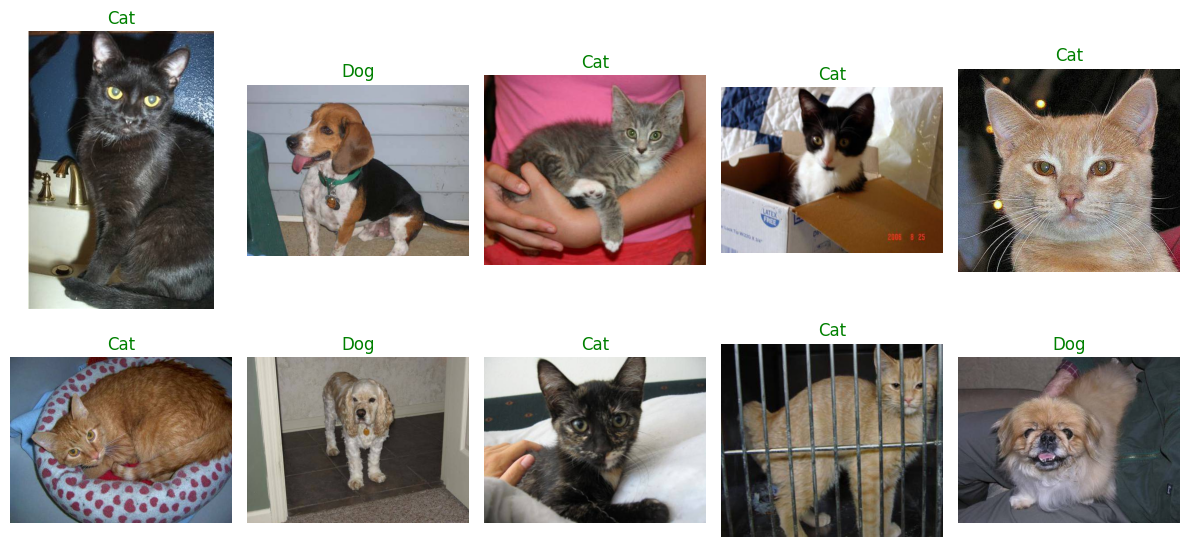

In [ ]:
display_image_grid(test_images_filepaths)

이미지 데이터셋 클래스 정의

In [ ]:
class DogvsCatDataset(Dataset):
  def __init__(self, file_list, transform=None, phase='train'): # 데이터셋의 전처리(데이터 변형 적용)
   self.file_list = file_list
   self.transform = transform # DogvsCatDataset 클래스를 호출할 때 transform에 대한 매개변수를 받아 옴
   self.phase = phase # 'train' 적용

  def __len__(self): # images_filepaths 데이터셋의 전체 길이를 반환
    return len(self.file_list)

  def __getitem__(self, idx): # 데이터셋에서 데이터를 가져오는 부분으로 결과는 텐서 형태가 됨
    img_path = self.file_list[idx]
    img = Image.open(img_path) # img_path 위치에서 이미지 데이터들을 가져옴
    img_transformed = self.transform(img, self.phase) # 이미지에 'train' 전처리를 적용
    label = img_path.split('/')[-1].split('.')[0]
    if label == 'dog':
      label = 1
    elif label == 'cat':
      label = 0
    return img_transformed, label

변수 값 정의

In [ ]:
size = 224
mean = (0.485, 0.456, 0.406)
std = (0.229, 0.224, 0.225)
batch_size = 32

이미지 데이터셋 정의

In [ ]:
train_dataset = DogvsCatDataset(train_images_filepaths, transform=ImageTransform(size, mean, std), phase='train') # 훈련 이미지에 train_transformers 적용
val_dataset = DogvsCatDataset(val_images_filepaths, transform=ImageTransform(size, mean, std), phase='val') # 검증 이미지에 val_transformers 적용

index = 0
print(train_dataset.__getitem__(index)[0].size()) # 훈련 데이터(train_dataset.__getitem__[0][0])의 크기(size()) 출력
print(train_dataset.__getitem__(index)[1]) # 훈련 데이터의 레이블 출력

torch.Size([3, 224, 224])
0


데이터로더 정의

In [ ]:
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
dataloader_dict = {'train': train_dataloader, 'val': val_dataloader} # 훈련 데이터셋과 검증 데이터셋을 합쳐서 표현

batch_iterator = iter(train_dataloader)
inputs, label = next(batch_iterator)
print(inputs.size())
print(label)

torch.Size([32, 3, 224, 224])
tensor([0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1,
        0, 0, 0, 1, 0, 1, 0, 0])


모델의 네트워크 클래스

In [ ]:
class LeNet(nn.Module):
  def __init__(self):
    super(LeNet, self).__init__()

    self.cnn1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=5, stride=1, padding=0) # 2D 합성곱층이 적용된다. 이때 입력 형태는 (3,224,224)가 되며 출력 형태는 (weight-kernel_size+1)/stride에 따라 (16,220,220)이 된다.

    self.relu1 = nn.ReLU() # ReLU 활성화 함수
    self.maxpool1 = nn.MaxPool2d(kernel_size=2) # 최대 풀링이 적용된다. 적용 이후 출력 형태는 220/2가 되어 (16,110,110)이다.
    self.cnn2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=5, stride=1, padding=0) # 2D 합성곱층이 적용되며 출력 형태는 (32,106,106)이다.
    self.relu2 = nn.ReLU()
    self.maxpool2 = nn.MaxPool2d(kernel_size=2) # 최대 풀링이 적용된다. 적용 이후 출력 형태는 (32,53,53)이다.

    self.fc1 = nn.Linear(32*53*53, 512)
    self.relu5 = nn.ReLU()
    self.fc2 = nn.Linear(512,2)
    self.output = nn.Softmax(dim=1)

  def forward(self, x):
    out = self.cnn1(x)
    out = self.relu1(out)
    out = self.maxpool1(out)
    out = self.cnn2(out)
    out = self.relu2(out)
    out = self.maxpool2(out)
    out = out.view(out.size(0),-1) # 완전연결층에 데이터를 전달하기 위해 데이터 형태를 1차원으로 바꾼다.
    out = self.fc1(out)
    out = self.fc2(out)
    out = self.output(out)
    return out

모델 객체 생성

In [ ]:
model = LeNet()
print(model)

LeNet(
  (cnn1): Conv2d(3, 16, kernel_size=(5, 5), stride=(1, 1))
  (relu1): ReLU()
  (maxpool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (cnn2): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1))
  (relu2): ReLU()
  (maxpool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=89888, out_features=512, bias=True)
  (relu5): ReLU()
  (fc2): Linear(in_features=512, out_features=2, bias=True)
  (output): Softmax(dim=1)
)


torchsummary 라이브러리 설치

In [48]:
pip install torchsummary

torchsummary 라이브러리를 이용한 모델의 네트워크 구조 확인

In [ ]:
from torchsummary import summary
summary(model, input_size=(3,224,224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 16, 220, 220]           1,216
              ReLU-2         [-1, 16, 220, 220]               0
         MaxPool2d-3         [-1, 16, 110, 110]               0
            Conv2d-4         [-1, 32, 106, 106]          12,832
              ReLU-5         [-1, 32, 106, 106]               0
         MaxPool2d-6           [-1, 32, 53, 53]               0
            Linear-7                  [-1, 512]      46,023,168
            Linear-8                    [-1, 2]           1,026
           Softmax-9                    [-1, 2]               0
Total params: 46,038,242
Trainable params: 46,038,242
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.57
Forward/backward pass size (MB): 19.47
Params size (MB): 175.62
Estimated Total Size (MB): 195.67
--------------------------------

학습 가능한 파라미터 수 확인

In [ ]:
def count_parameters(model):
  return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'The model has {count_parameters(model):,} trainable parameters')

The model has 46,038,242 trainable parameters


옵티마이저와 손실 함수 정의

In [ ]:
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
criterion = nn.CrossEntropyLoss()

모델의 파라미터와 손실 함수를 CPU에 할당

In [ ]:
model = model.to(device)
criterion = criterion.to(device)

모델 학습 함수 정의

In [ ]:
from IPython.core.interactiveshell import SingletonConfigurable
def train_model(model, dataloader_dict, criterion, optimizer, num_epoch):
  since = time.time()
  best_acc = 0.0

  for epoch in range(num_epoch): # epoch을 10으로 설정했으므로 10회 반복
    print('Epoch {}/{}'.format(epoch+1, num_epoch))
    print('-'*20)

    for phase in ['train', 'val']:
      if phase == 'train':
        model.train() # 모델을 학습시키겠다는 의미
      else:
        model.eval()

      epoch_loss = 0.0
      epoch_corrects = 0

      for inputs, labels in tqdm(dataloader_dict[phase]): # dataloader_dict는 훈련 데이터셋(train_loader)을 의미
        inputs = inputs.to(device) # 훈련 데이터셋을 CPU에 할당
        labels = labels.to(device)
        optimizer.zero_grad() # 역전파 단계를 실행하기 전에 기울기를 0으로 초기화

        with torch.set_grad_enabled(phase == 'train'):
          outputs = model(inputs)
          _, preds = torch.max(outputs, 1)
          loss = criterion(outputs, labels) # 손실함수를 이용한 오차 계산

          if phase == 'train':
            loss.backward() # 모델의 학습 가능한 모든 파라미터에 대해 기울기 계산
            optimizer.step() # optimizer의 step 함수 호출해 파라미터 갱신

          epoch_loss += loss.item() * inputs.size(0)
          epoch_corrects += torch.sum(preds == labels.data) # 정답과 예측이 일치하면 그것의 합계를 epoch_corrects에 저장

      epoch_loss = epoch_loss / len(dataloader_dict[phase].dataset) # 최종 오차 계산(초라를 데이터셋의 길이(개수)로 나누어 계산)
      epoch_acc = epoch_corrects.double() / len(dataloader_dict[phase].dataset) # 최종 정확도(epoch_corrects를 데이터셋의 길이(개수)로 나누어 계산)

      print('{} Loss: {:.4f} Acc: {:.4f}'.format(phase, epoch_loss, epoch_acc))

      if phase == 'val' and epoch_acc > best_acc: # 검증 데이터셋에 대한 가장 최적의 정확도를 저장
        best_acc = epoch_acc
        best_model_wts = model.state_dict()

  time_elapsed = time.time() - since
  print('Training complete in {:.0f}m {:.0f}s'.format(
      time_elapsed // 60, time_elapsed % 60))
  print('Best val Acc: {:4f}'.format(best_acc))
  return model


모델 학습

In [ ]:
import time

num_epoch = 10
model = train_model(model, dataloader_dict, criterion, optimizer, num_epoch)

Epoch 1/10
--------------------


/tmp/ipykernel_1417/138407053.py:19: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for inputs, labels in tqdm(dataloader_dict[phase]): # dataloader_dict는 훈련 데이터셋(train_loader)을 의미


  0%|          | 0/13 [00:00<?, ?it/s]

train Loss: 0.6314 Acc: 0.6500


  0%|          | 0/3 [00:00<?, ?it/s]

...

val Loss: 0.6922 Acc: 0.5543
Epoch 10/10
--------------------


  0%|          | 0/13 [00:00<?, ?it/s]

train Loss: 0.6216 Acc: 0.6600


  0%|          | 0/3 [00:00<?, ?it/s]

val Loss: 0.6718 Acc: 0.5978
Training complete in 5m 33s
Best val Acc: 0.597826


모델 테스트를 위한 함수 정의

In [ ]:
import pandas as pd

id_list = []
pred_list = []
_id = 0
with torch.no_grad(): # 역전파 중 텐서에 대한 변화도를 계산할 필요가 없음을 나타내는 것으로, 훈련 데이터셋의 모델 학습과 가장 큰 차이점이다.
  for test_path in tqdm(test_images_filepaths): # 테스트 데이터셋 이용
    img = Image.open(test_path)
    _id = test_path.split('/')[-1].split('.')[1]
    transform = ImageTransform(size, mean, std)
    img = transform(img, phase='val') # 테스트 데이터셋 전처리 적용
    img = img.unsqueeze(0)
    img = img.to(device)

    model.eval()
    outputs = model(img)
    preds = F.softmax(outputs, dim=1)[:,1].tolist()
    id_list.append(_id)
    pred_list.append(preds[0])

  res = pd.DataFrame({'id':id_list, 'label':pred_list}) # 테스트 데이터셋의 예측 결과인 id와 레이블을 데이터 프레임에 저장

  res.sort_values(by='id', inplace=True)
  res.reset_index(drop=True, inplace=True)

  res.to_csv('/content/drive/MyDrive/data/LeNet', index=False) # 데이터 프레임을 CSV 파일로 저장

/tmp/ipykernel_1417/2131896254.py:7: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for test_path in tqdm(test_images_filepaths): # 테스트 데이터셋 이용


  0%|          | 0/10 [00:00<?, ?it/s]

테스트 데이터셋의 예측 결과 호출

In [ ]:
res.head(10)

,id,label
0,109,0.288891
1,145,0.286602
2,15,0.544323
3,162,0.369177
4,167,0.506618
5,200,0.290488
6,210,0.560790
7,211,0.446696
8,213,0.296178
9,224,0.622251


테스트 데이터셋 이미지를 출력하기 위한 함수 정의

In [ ]:
class_ = classes = {0:'cat', 1:'dog'} # 개와 고양이에 대한 클래스 정의
def display_image_grid(images_filepaths, predicted_labels=(), cols=5):
    rows = len(images_filepaths) // cols
    figure, ax = plt.subplots(nrows=rows, ncols=cols, figsize=(12, 6))
    for i, image_filepath in enumerate(images_filepaths):
        image = cv2.imread(image_filepath)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        true_label = os.path.normpath(image_filepath).split(os.sep)[-2]
        predicted_label = predicted_labels[i] if predicted_labels else true_label
        color = "green" if true_label == predicted_label else "red"
        ax.ravel()[i].imshow(image)
        ax.ravel()[i].set_title(predicted_label, color=color)
        ax.ravel()[i].set_axis_off()
    plt.tight_layout()
    plt.show()

테스트 데이터셋 예측 결과 이미지 출력

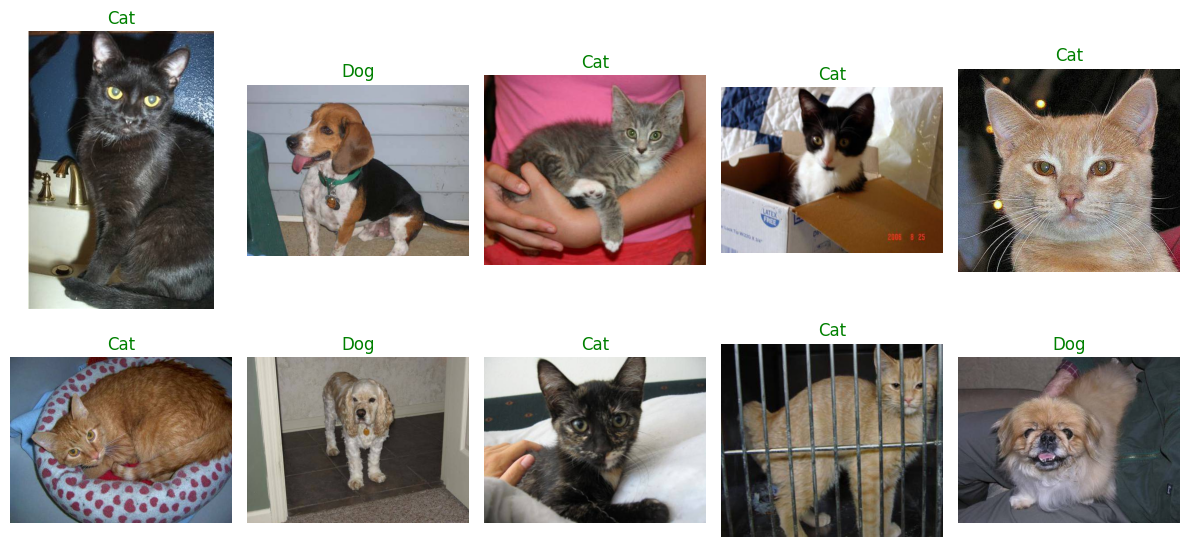

In [ ]:
display_image_grid(test_images_filepaths)

#### 6.1.2 AlexNet

필요한 라이브러리 호출

In [1]:
import torch
import torchvision
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torch.autograd import Variable
from torch import optim
import torch.nn as nn
import torch.nn.functional as F
import os
import cv2
import random
from PIL import Image
from tqdm import tqdm_notebook as tqdm
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

데이터 전처리

In [35]:
class ImageTransform():
  def __init__(self, resize, mean, std):
    self.data_transform = {
        'train': transforms.Compose([
            transforms.RandomResizedCrop(resize,scale=(0.5,1.0)),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize(mean,std)
        ]),
        'val': transforms.Compose([
            transforms.Resize(256),
            transforms.CenterCrop(resize),
            transforms.ToTensor(),
            transforms.Normalize(mean,std)
        ])
    }

  def __call__(self, img, phase):
    return self.data_transform[phase](img)

데이터를 가져와서 훈련, 검증, 테스트 용도로 분리

In [36]:
cat_directory = r"/content/drive/MyDrive/data/dogs-vs-cats/Cat/"
dog_directory = r"/content/drive/MyDrive/data/dogs-vs-cats/Dog/"

cat_images_filepaths = sorted([os.path.join(cat_directory, f) for f in
                               os.listdir(cat_directory)])
dog_images_filepaths = sorted([os.path.join(dog_directory, f) for f in
                               os.listdir(dog_directory)])
images_filepaths = [*cat_images_filepaths, *dog_images_filepaths]
correct_images_filepaths = [i for i in images_filepaths if cv2.imread(i) is not None]

random.seed(42)
random.shuffle(correct_images_filepaths)
train_images_filepaths = correct_images_filepaths[:400] # 훈련용 400개의 이미지
val_images_filepaths = correct_images_filepaths[400:-10] # 검증용 92개의 이미지
test_images_filepaths = correct_images_filepaths[-10:] # 테스트용 10개의 이미지
print(len(train_images_filepaths), len(val_images_filepaths), len(test_images_filepaths))

400 92 10


커스텀 데이터셋 정의

In [37]:
class DogvsCatDataset(Dataset):
    def __init__(self, file_list, transform=None, phase='train'):
        self.file_list = file_list
        self.transform = transform
        self.phase = phase

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        img_path = self.file_list[idx]
        img = Image.open(img_path)
        img_transformed = self.transform(img, self.phase)

        label = img_path.split('/')[-1].split('.')[0]
        if label == 'dog':
            label = 1
        elif label == 'cat':
            label = 0

        return img_transformed, label

변수에 대한 값 정의

In [38]:
size = 256 # AlexNet은 깊이가 깊은 네트워크를 사용하므로 이미지 크기가 256이 아니면 풀링층 때문에 크기가 계속 줄어들어 오류가 발생할 수 있다.
mean = (0.485, 0.456, 0.406)
std = (0.229, 0.224, 0.225)
batch_size = 32

훈련, 검증, 테스트 데이터셋 정의

In [41]:
train_dataset = DogvsCatDataset(train_images_filepaths, transform=ImageTransform(size, mean, std), phase='train')
val_dataset = DogvsCatDataset(val_images_filepaths, transform=ImageTransform(size, mean, std), phase='val')
test_dataset = DogvsCatDataset(val_images_filepaths, transform=ImageTransform(size, mean, std), phase='val')

index = 0
print(train_dataset.__getitem__(index)[0].size())
print(train_dataset.__getitem__(index)[1])

torch.Size([3, 256, 256])
0


데이터셋을 메모리로 불러옴

In [43]:
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
dataloader_dict = {'train': train_dataloader, 'val': val_dataloader}

batch_iterator = iter(train_dataloader)
inputs, label = next(batch_iterator)
print(inputs.size())
print(label)

torch.Size([32, 3, 256, 256])
tensor([0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0,
        0, 1, 0, 1, 0, 0, 1, 1])


AlexNet 모델 네트워크 정의

In [53]:
class AlexNet(nn.Module):
  def __init__(self) -> None:
    super(AlexNet, self).__init__()
    self.features = nn.Sequential(
        nn.Conv2d(3, 64, kernel_size=11, stride=4, padding=2),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=3, stride=2),
        nn.Conv2d(64, 192, kernel_size=5, padding=2),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=3, stride=2),
        nn.Conv2d(192, 384, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
        nn.Conv2d(384, 256, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=3, stride=2),
    )
    self.avgpool = nn.AdaptiveAvgPool2d((6, 6))
    self.classifier = nn.Sequential(
        nn.Dropout(),
        nn.Linear(256 * 6 * 6, 4096),
        nn.ReLU(inplace=True),
        nn.Dropout(),
        nn.Linear(4096, 512),
        nn.ReLU(inplace=True),
        nn.Linear(512,2),
    )

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    x = self.features(x)
    x = self.avgpool(x)
    x = torch.flatten(x, 1)
    x = self.classifier(x)
    return x

model 객체 생성

In [54]:
model = AlexNet()
model.to(device)

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=4096, out_fea

옵티마이저 및 손실 함수 정의

In [55]:
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
criterion = nn.CrossEntropyLoss()

모델 네트워크 구조 확인

In [56]:
from torchsummary import summary
summary(model, input_size=(3,256,256))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 63, 63]          23,296
              ReLU-2           [-1, 64, 63, 63]               0
         MaxPool2d-3           [-1, 64, 31, 31]               0
            Conv2d-4          [-1, 192, 31, 31]         307,392
              ReLU-5          [-1, 192, 31, 31]               0
         MaxPool2d-6          [-1, 192, 15, 15]               0
            Conv2d-7          [-1, 384, 15, 15]         663,936
              ReLU-8          [-1, 384, 15, 15]               0
            Conv2d-9          [-1, 256, 15, 15]         884,992
             ReLU-10          [-1, 256, 15, 15]               0
        MaxPool2d-11            [-1, 256, 7, 7]               0
AdaptiveAvgPool2d-12            [-1, 256, 6, 6]               0
          Dropout-13                 [-1, 9216]               0
           Linear-14                 [-

모델 학습 함수 정의

In [59]:
import time
def train_model(model, dataloader_dict, criterion, optimizer, num_epoch):
  since = time.time()
  best_acc = 0.0

  for epoch in range(num_epoch):
    print('Epoch {}/{}'.format(epoch+1, num_epoch))
    print('-'*20)

    for phase in ['train', 'val']:
      if phase == 'train':
        model.train()
      else:
        model.eval()

      epoch_loss = 0.0
      epoch_corrects = 0

      for inputs, labels in tqdm(dataloader_dict[phase]):
        inputs = inputs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()

        with torch.set_grad_enabled(phase == 'train'):
          outputs = model(inputs)
          _, preds = torch.max(outputs, 1)
          loss = criterion(outputs, labels)

          if phase == 'train':
            loss.backward()
            optimizer.step()

          epoch_loss += loss.item() * inputs.size(0)
          epoch_corrects += torch.sum(preds == labels.data)

      epoch_loss = epoch_loss / len(dataloader_dict[phase].dataset)
      epoch_acc = epoch_corrects.double() / len(dataloader_dict[phase].dataset)

      print('{} Loss: {:.4f} Acc: {:.4f}'.format(phase, epoch_loss, epoch_acc))

      if phase == 'val' and epoch_acc > best_acc:
        best_acc = epoch_acc
        best_model_wts = model.state_dict()

  time_elapsed = time.time() - since
  print('Training complete in {:.0f}m {:.0f}s'.format(
      time_elapsed // 60, time_elapsed % 60))
  return model

모델 학습

In [60]:
num_epoch = 10
model = train_model(model, dataloader_dict, criterion, optimizer, num_epoch)

Epoch 1/10
--------------------


/tmp/ipykernel_4090/885515448.py:19: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for inputs, labels in tqdm(dataloader_dict[phase]):


  0%|          | 0/13 [00:00<?, ?it/s]

train Loss: 0.6941 Acc: 0.4750


/tmp/ipykernel_4090/885515448.py:19: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for inputs, labels in tqdm(dataloader_dict[phase]):


...

val Loss: 0.6917 Acc: 0.5109
Epoch 10/10
--------------------


  0%|          | 0/13 [00:00<?, ?it/s]

train Loss: 0.6919 Acc: 0.5150


  0%|          | 0/3 [00:00<?, ?it/s]

val Loss: 0.6917 Acc: 0.5109
Training complete in 7m 52s


모델을 이용한 예측

In [61]:
import pandas as pd

id_list = []
pred_list = []
_id = 0
with torch.no_grad():
  for test_path in tqdm(test_images_filepaths): # 테스트 이미지 데이터 이용
    img = Image.open(test_path)
    _id = test_path.split('/')[-1].split('.')[1] # 이미지 데이터의 번호 가져오기 (예를 들어 dog.113.jpg라는 이미지 이름에서 113 가져오기)
    transform = ImageTransform(size, mean, std)
    img = transform(img, phase='val') # 테스트 데이터에 검증용 전처리 적용
    img = img.unsqueeze(0)
    img = img.to(device)

    model.eval()
    outputs = model(img)
    preds = F.softmax(outputs, dim=1)[:,1].tolist()
    id_list.append(_id)
    pred_list.append(preds[0])

  res = pd.DataFrame({'id':id_list, 'label':pred_list}) # 데이터 프레임에 이미지 id와 레이블 저장

  res.to_csv('/content/drive/MyDrive/data/alexNet.csv', index=False) # 이미지의 id와 레이블을 alexnet.csv 파일에 저장

/tmp/ipykernel_4090/3657621591.py:7: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for test_path in tqdm(test_images_filepaths): # 테스트 이미지 데이터 이용


  0%|          | 0/10 [00:00<?, ?it/s]

데이터 프레임 결과 확인

In [62]:
res.head(10)

,id,label
0,145,0.511708
1,211,0.516832
2,162,0.513451
3,200,0.520608
4,210,0.514900
5,224,0.510934
6,213,0.512825
7,109,0.518171
8,15,0.511769
9,167,0.510303


예측 결과를 시각적으로 표현하기 위한 함수 정의

In [67]:
from matplotlib import pyplot as plt
class_ = classes = {0:'cat', 1:'dog'}
def display_image_grid(images_filepaths, predicted_labels=(), cols=5):
    rows = len(images_filepaths) // cols
    figure, ax = plt.subplots(nrows=rows, ncols=cols, figsize=(12, 6))
    for i, image_filepath in enumerate(images_filepaths):
        image = cv2.imread(image_filepath)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        a = random.choice(res['id'].values)
        label = res.loc[res['id'] == a, 'label'].values[0]
        if label > 0.5:
          label = 1
        else:
          label = 0

        ax.ravel()[i].imshow(image)
        ax.ravel()[i].set_title(class_[label])
        ax.ravel()[i].set_axis_off()
    plt.tight_layout()
    plt.show()

예측 결과에 대해 이미지와 함께 출력

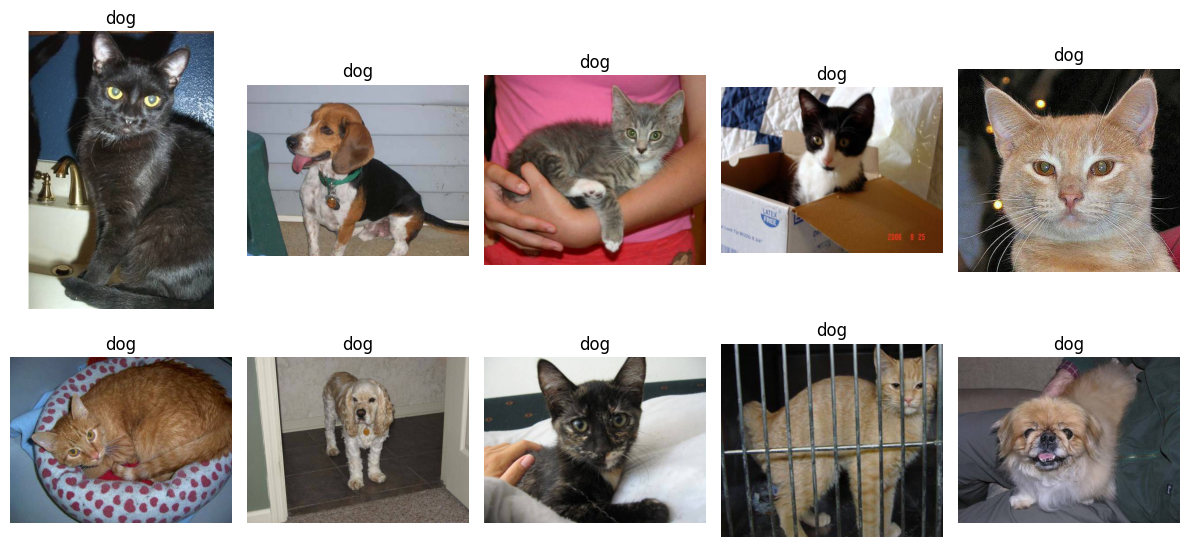

In [68]:
display_image_grid(test_images_filepaths)

#### 6.1.3 VGGNet

필요한 라이브러리 호출

In [1]:
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as Datasets

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

VGG 모델 정의

In [2]:
class VGG(nn.Module):
  def __init__(self, features, output_dim):
    super().__init__()
    self.features = features # VGG 모델에 대한 매개변수에서 받아 온 features 값을 self.features에 넣어 줌
    self.avgpool = nn.AdaptiveAvgPool2d(7)
    self.classifier = nn.Sequential(
        nn.Linear(512*7*7, 4096),
        nn.ReLU(inplace=True),
        nn.Dropout(0.5),
        nn.Linear(4096, 4096),
        nn.ReLU(inplace=True),
        nn.Dropout(0.5),
        nn.Linear(4096, output_dim)
    ) # 완전연결층과 출력층 정의

  def forward(self, x):
    x = self.features(x)
    x = self.avgpool(x)
    h = x.view(x.shape[0], -1)
    x = self.classifier(h)
    return x, h

모델 유형 정의

In [3]:
vgg11_config = [64, 'M', 128, 'M', 256, 256, 'M', 512, 512, 'M', 512, 512, 'M'] # 8(합성곱층)+3(풀링층)=11(전체 계층)=VGG11
vgg13_config = [64, 64, 'M', 128, 128, 'M', 256, 256, 'M', 512, 512, 'M', 512, 512, 'M'] # 10(합성곱층)+3(풀링층)=13(전체 계층)=VGG13
vgg16_config = [64, 64, 'M', 128, 128, 'M', 256, 256, 256, 'M', 512, 512, 512, 'M', 512, 512, 512, 'M'] # 13(합성곱층)+3(풀링층)=16(전체 계층)=VGG16
vgg19_config = [64, 64, 'M', 128, 128, 'M', 256, 256, 256, 256, 'M', 512, 512, 512, 512, 'M', 512, 512, 512, 512, 'M'] # 16(합성곱층)+3(풀링층)=19(전체 계층)=VGG19

VGG 계층 정의

In [4]:
def get_vgg_layers(config, batch_norm):
  layers = []
  in_channels = 3

  for c in config : # vgg11_config 값들을 가져옴
    assert c == 'M' or isinstance(c, int)
    if c == 'M': # 불러온 값이 'M'이면 최대 풀링 적용
      layers += [nn.MaxPool2d(kernel_size = 2)]
    else: # 불러온 값이 숫자이면 합성곱(Conv2d) 적용
      conv2d = nn.Conv2d(in_channels, c, kernel_size=3, padding=1)
      if batch_norm: # 배치 정규화를 적용할지에 대한 코드
        layers += [conv2d, nn.BatchNorm2d(c), nn.ReLU(inplace=True)] # 배치 정규화가 적용될 경우 배치 정규화+ReLU 적용
      else:
        layers += [conv2d, nn.ReLU(inplace=True)] # 배치 정규화가 적용되지 않을 경우 ReLU만 적용
      in_channels = c

  return nn.Sequential(*layers) # 네트워크의 모든 계층 반환

모델 계층 생성

In [5]:
vgg11_layers = get_vgg_layers(vgg11_config, batch_norm=True)

VGG11 계층 확인

In [6]:
print(vgg11_layers)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): ReLU(inplace=True)
  (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (10): ReLU(inplace=True)
  (11): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (12): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (13): ReLU(inplace=True)
  (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, cei

VGG11 전체에 대한 네트워크

In [7]:
OUTPUT_DIM = 2 # 개와 고양이 두 클래스 사용
model = VGG(vgg11_layers, OUTPUT_DIM)
print(model)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU(inplace=True)
    (14): MaxPool2d(ke

VGG11 사전 훈련된 모델 사용

In [8]:
import torchvision.models as models
pretrained_model = models.vgg11_bn(pretrained=True)
print(pretrained_model)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG11_BN_Weights.IMAGENET1K_V1`. You can also use `weights=VGG11_BN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg11_bn-6002323d.pth" to /root/.cache/torch/hub/checkpoints/vgg11_bn-6002323d.pth


100%|██████████| 507M/507M [00:06<00:00, 80.6MB/s]


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU(inplace=True)
    (14): MaxPool2d(ke

이미지 데이터 전처리

In [9]:
train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomRotation(5),
    transforms.RandomHorizontalFlip(0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.456], std=[0.229, 0.224, 0.225])
])

ImageFolder를 이용하여 데이터셋 불러오기

In [11]:
train_path = "/content/drive/MyDrive/data/catanddog/train" # 훈련 데이터셋 경로
test_path = "/content/drive/MyDrive/data/catanddog/test" # 테스트 데이터셋 경로

train_dataset = torchvision.datasets.ImageFolder(
    train_path,
    transform=train_transforms
)

test_dataset = torchvision.datasets.ImageFolder(
    test_path,
    transform=test_transforms
)

print(len(train_dataset))
print(len(test_dataset))

538
12


훈련과 검증 데이터 분할

In [12]:
VALID_RATIO = 0.9
n_train_examples = int(len(train_dataset) * VALID_RATIO) # 전체 훈련 데이터 중 90%를 훈련 데이터셋으로 사용
n_valid_examples = len(train_dataset) - n_train_examples # 전체 훈련 데이터 중 10%를 검증 데이터셋으로 사용
train_data, valid_data = data.random_split(train_dataset, [n_train_examples, n_valid_examples])

검증 데이터 전처리

In [13]:
valid_data = copy.deepcopy(valid_data)
valid_data.dataset.transform = test_transforms

훈련, 검증, 테스트 데이터셋 수 확인`

In [14]:
print(f'Number of training examples: {len(train_data)}')
print(f'Number of validation examples: {len(valid_data)}')
print(f'Number of testing examples: {len(test_dataset)}')

Number of training examples: 484
Number of validation examples: 54
Number of testing examples: 12


메모리로 데이터 불러오기

In [15]:
BATCH_SIZE = 16
train_iterator = data.DataLoader(train_data,
                                 shuffle=True,
                                 batch_size=BATCH_SIZE) # 훈련 데이터셋은 임의로 섞어서 가져옴

valid_iterator = data.DataLoader(valid_data,
                                 batch_size=BATCH_SIZE)

test_iterator = data.DataLoader(test_dataset,
                                batch_size=BATCH_SIZE)

옵티마이저와 손실 함수 정의

In [16]:
optimizer = optim.Adam(model.parameters(), lr=1e-7)
criterion = nn.CrossEntropyLoss()

model = model.to(device)
criterion = criterion.to(device)

모델 정확도 측정 함수

In [17]:
def calculate_accuracy(y_pred, y):
  top_pred = y_pred.argmax(1, keepdim=True)
  correct = top_pred.eq(y.view_as(top_pred)).sum()
  acc = correct.float() / y.shape[0]
  return acc

모델 학습 함수 정의

In [18]:
def train(model, iterator, optimizer, criterion, device):
  epoch_loss = 0
  epoch_acc = 0

  model.train()
  for (x,y) in iterator:
    x = x.to(device)
    y = y.to(device)

    optimizer.zero_grad()
    y_pred, _ = model(x)
    loss = criterion(y_pred, y)
    acc = calculate_accuracy(y_pred, y)
    loss.backward()
    optimizer.step()

    epoch_loss += loss.item()
    epoch_acc += acc.item()

  return epoch_loss / len(iterator), epoch_acc / len(iterator)

모델 성능 측정 함수

In [19]:
def evaluate(model, iterator, criterion, device):
  epoch_loss = 0
  epoch_acc = 0

  model.eval()
  with torch.no_grad():
    for (x,y) in iterator:
      x = x.to(device)
      y = y.to(device)
      y_pred, _ = model(x)
      loss = criterion(y_pred, y)
      acc = calculate_accuracy(y_pred, y)

      epoch_loss += loss.item()
      epoch_acc += acc.item()

  return epoch_loss / len(iterator), epoch_acc / len(iterator)

학습 시간 측정 함수

In [20]:
def epoch_time(start_time, end_time):
  elapsed_time = end_time - start_time
  elapsed_mins = int(elapsed_time / 60)
  elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
  return elapsed_mins, elapsed_secs

모델 학습

In [21]:
import time

EPOCHS = 5
best_valid_loss = float('inf')
for epoch in range(EPOCHS):
  start_time = time.monotonic()
  train_loss, train_acc = train(model, train_iterator, optimizer, criterion, device) # 훈련 데이터셋을 모델에 적용한 결과(오차와 정확도)를 train_loss와 train_acc에 저장
  valid_loss, valid_acc = evaluate(model, valid_iterator, criterion, device) # 검증 데이터셋을 모델에 적용한 결과(오차와 정확도)를 valid_loss와 valid_acc에 저장

  if valid_loss < best_valid_loss: # valid_loss가 가장 작은 값을 구하고 그 상태의 모델을 VGG-model.pt 이름으로 저장
    best_valid_loss = valid_loss
    torch.save(model.state_dict(), '/content/drive/MyDrive/data/VGG-model.pt')

  end_time = time.monotonic()
  epoch_mins, epoch_secs = epoch_time(start_time, end_time) # 모델 훈련에 대한 시작과 종료 시간을 저장

  print(f'Epoch: {epoch+1:02} | Epoch Time: {epoch_mins}m {epoch_secs}s')
  print(f'\tTrain Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}%')
  print(f'\t Valid. Loss: {valid_loss:.3f} |  Valid. Acc: {valid_acc*100:.2f}%')


Epoch: 01 | Epoch Time: 2m 10s
	Train Loss: 0.699 | Train Acc: 50.40%
	 Valid. Loss: 0.696 |  Valid. Acc: 34.90%
Epoch: 02 | Epoch Time: 0m 25s
	Train Loss: 0.709 | Train Acc: 47.98%
	 Valid. Loss: 0.693 |  Valid. Acc: 47.92%
Epoch: 03 | Epoch Time: 0m 26s
	Train Loss: 0.684 | Train Acc: 54.23%
	 Valid. Loss: 0.693 |  Valid. Acc: 46.35%
Epoch: 04 | Epoch Time: 0m 29s
	Train Loss: 0.701 | Train Acc: 48.79%
	 Valid. Loss: 0.691 |  Valid. Acc: 51.04%
Epoch: 05 | Epoch Time: 0m 25s
	Train Loss: 0.690 | Train Acc: 53.63%
	 Valid. Loss: 0.692 |  Valid. Acc: 47.92%


테스트 데이터셋을 이용한 모델 성능 측정

In [22]:
model.load_state_dict(torch.load('/content/drive/MyDrive/data/VGG-model.pt'))
test_loss, test_acc = evaluate(model, test_iterator, criterion, device)
print(f'Test Loss: {test_loss: .3f} | Test Acc: {test_acc*100: .2f}%')

Test Loss:  0.685 | Test Acc:  58.33%


테스트 데이터셋을 이용한 모델의 예측 확인 함수

In [23]:
def get_predictions(model, iterator):
  model.eval()
  images = []
  labels = []
  probs = []

  with torch.no_grad():
    for (x,y) in iterator:
      x = x.to(device)
      y_pred, _ = model(x)
      y_prob = F.softmax(y_pred, dim=-1)
      top_pred = y_prob.argmax(1, keepdim=True)
      images.append(x.cpu())
      labels.append(y.cpu())
      probs.append(y_prob.cpu())

  images = torch.cat(images, dim=0)
  labels = torch.cat(labels, dim=0)
  probs = torch.cat(probs, dim=0)
  return images, labels, probs

예측 중에서 정확하게 예측한 것을 추출

In [24]:
images, labels, probs = get_predictions(model, test_iterator)
pred_labels = torch.argmax(probs, 1)
corrects = torch.eq(labels, pred_labels) # 예측과 정답이 같은지 비교
correct_examples = []

for image, label, prob, correct in zip(images, labels, probs, corrects):
  if correct:
    correct_examples.append((image, label, prob))

correct_examples.sort(reverse=True, key=lambda x: torch.max(x[2], dim=0).values)

이미지 출력을 위한 전처리

In [25]:
def normalize_image(image):
  image_min = image.min()
  image_max = image.max()
  image.clamp_(min=image_min, max=image_max) # torch.clamp는 주어진 최소, 최대의 범주에 이미지가 위치하도록 함
  image.add_(-image_min).div_(image_max - image_min +1e-5)
  return image

모델이 정확하게 예측한 이미지 출력 함수

In [27]:
def plot_most_correct(correct, classes, n_images, normalize=True):
  rows = int(np.sqrt(n_images)) # np.sqrt는 제곱근을 계산(0.5를 거듭제곱)
  cols = int(np.sqrt(n_images))
  fig = plt.figure(figsize=(25,20))
  for i in range(rows*cols):
    ax = fig.add_subplot(rows, cols, i+1) # 출력하려는 그래프 개수만큼 subplot을 만듦
    image, true_label, probs = correct[i]
    image = image.permute(1, 2, 0)
    true_prob = probs[true_label]
    correct_prob, correct_label = torch.max(probs, dim=0)
    true_class = classes[true_label]
    correct_class = classes[correct_label]

    if normalize: # 본래 이미지대로 출력하기 위해 normalize_image 함수 호출
      image = normalize_image(image)

    ax.imshow(image.cpu().numpy())
    ax.set_title(f'true label: {true_class} ({true_prob:.3f})\n' \
                     f'pred label: {correct_class} ({correct_prob:.3f})')
    ax.axis('off')

  fig.subplots_adjust(hspace=0.4)

예측 결과 이미지 출력

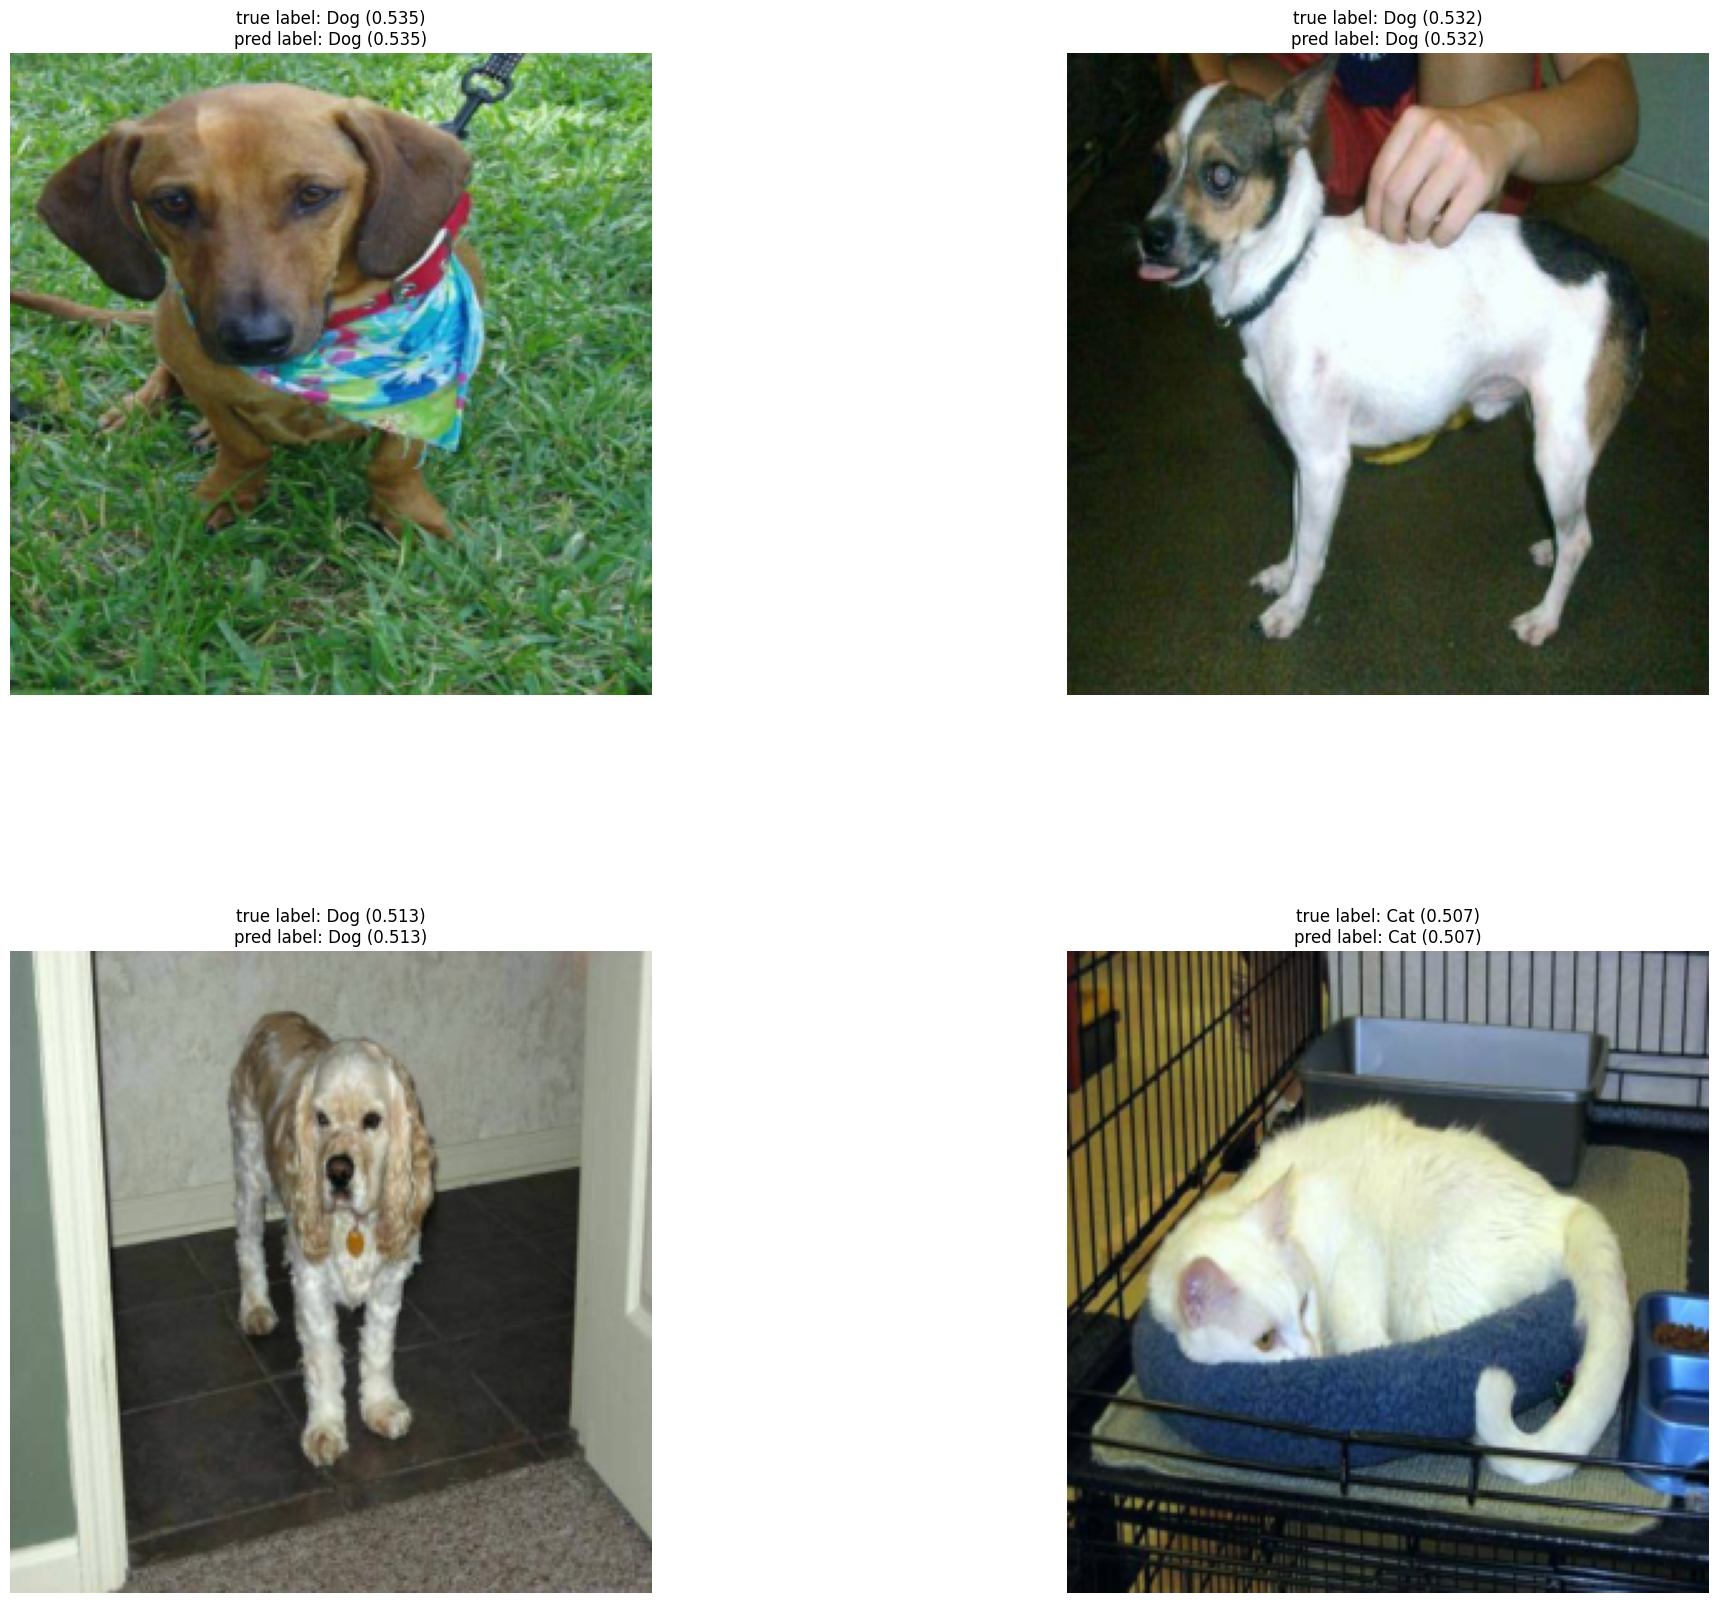

In [29]:
import matplotlib.pyplot as plt

classes = test_dataset.classes
N_IMAGES = 5
plot_most_correct(correct_examples, classes, N_IMAGES)